# Installation Test Notebook
Tests numpy, pandas, matplotlib, sklearn, torch, and lightkurve in one pass.

## 1. Library Versions

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import lightkurve as lk
import astropy

print(f'torch:       {torch.__version__}')
print(f'numpy:       {np.__version__}')
print(f'pandas:      {pd.__version__}')
print(f'sklearn:     {sklearn.__version__}')
print(f'lightkurve:  {lk.__version__}')
print(f'astropy:     {astropy.__version__}')
print(f'GPU:         {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU name:    {torch.cuda.get_device_name(0)}')

torch:       2.12.0.dev20260408+cu128
numpy:       2.4.3
pandas:      2.3.3
sklearn:     1.8.0
lightkurve:  2.6.0
astropy:     7.2.0
GPU:         True
GPU name:    NVIDIA GeForce RTX 5060 Laptop GPU


## 2. NumPy — Basic Matrix Operations
Connecting back to your linear algebra work.

In [2]:
# Create a simple matrix and compute eigenvalues
# You've seen this before in the linear algebra coding week!
A = np.array([[4, 2],
              [1, 3]])

eigenvalues, eigenvectors = np.linalg.eig(A)

print('Matrix A:')
print(A)
print(f'\nEigenvalues: {eigenvalues}')
print(f'Eigenvectors:\n{eigenvectors}')

Matrix A:
[[4 2]
 [1 3]]

Eigenvalues: [5. 2.]
Eigenvectors:
[[ 0.89442719 -0.70710678]
 [ 0.4472136   0.70710678]]


## 3. Pandas + Sklearn — Iris Dataset
The classic ML hello world — classify flower species from measurements.

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Load dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target_names[iris.target]

print(f'Dataset shape: {df.shape}')
print(f'\nFirst 5 rows:')
df.head()

Dataset shape: (150, 5)

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
# Train a simple classifier
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 4. Matplotlib — Visualize the Data

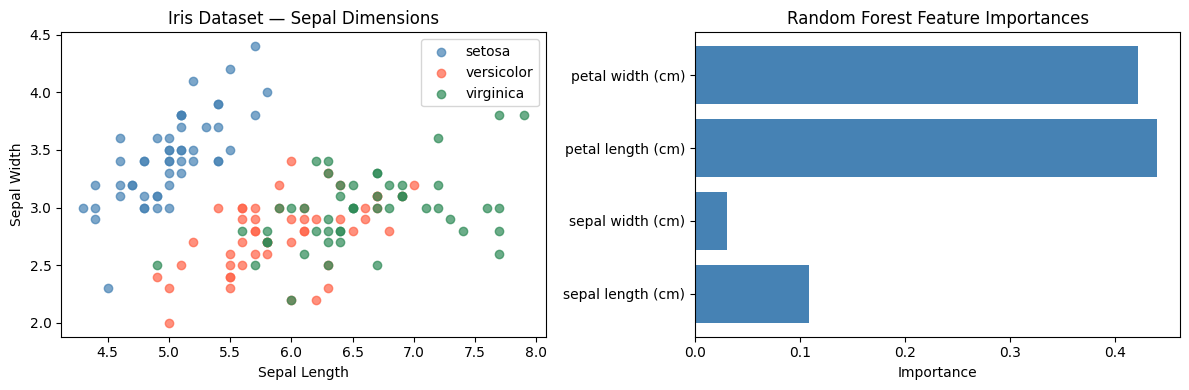

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1 — scatter by species
colors = ['steelblue', 'tomato', 'seagreen']
for i, species in enumerate(iris.target_names):
    mask = iris.target == i
    axes[0].scatter(
        iris.data[mask, 0], iris.data[mask, 1],
        label=species, color=colors[i], alpha=0.7
    )
axes[0].set_xlabel('Sepal Length')
axes[0].set_ylabel('Sepal Width')
axes[0].set_title('Iris Dataset — Sepal Dimensions')
axes[0].legend()

# Plot 2 — feature importances
importances = clf.feature_importances_
axes[1].barh(iris.feature_names, importances, color='steelblue')
axes[1].set_title('Random Forest Feature Importances')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

## 5. PyTorch — Tensors on GPU
Confirms your GPU is working with PyTorch.

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Create tensors and do a matrix multiply on GPU
A = torch.randn(1000, 1000).to(device)
B = torch.randn(1000, 1000).to(device)
C = torch.matmul(A, B)

print(f'Matrix multiply on {device}: {C.shape} ✅')
print(f'Result mean: {C.mean().item():.4f} (should be near 0)')

Using device: cuda
Matrix multiply on cuda: torch.Size([1000, 1000]) ✅
Result mean: 0.0263 (should be near 0)


## 6. Lightkurve — Download a Real Light Curve
Your first real NASA data. This downloads a Kepler light curve for a known exoplanet host star.

In [7]:
# Download light curve for Kepler-10 — host of the first confirmed rocky exoplanet
print('Downloading Kepler-10 light curve from MAST archive...')
search = lk.search_lightcurve('Kepler-10', author='Kepler', cadence='long')
print(f'Found {len(search)} data products')
print(search[:3])  # Show first 3

Found 15 data products
SearchResult containing 3 data products.

 #       mission      year author exptime  target_name  distance
                                     s                   arcsec 
--- ----------------- ---- ------ ------- ------------- --------
  0 Kepler Quarter 00 2009 Kepler    1800 kplr011904151      0.0
  1 Kepler Quarter 01 2009 Kepler    1800 kplr011904151      0.0
  2 Kepler Quarter 02 2009 Kepler    1800 kplr011904151      0.0


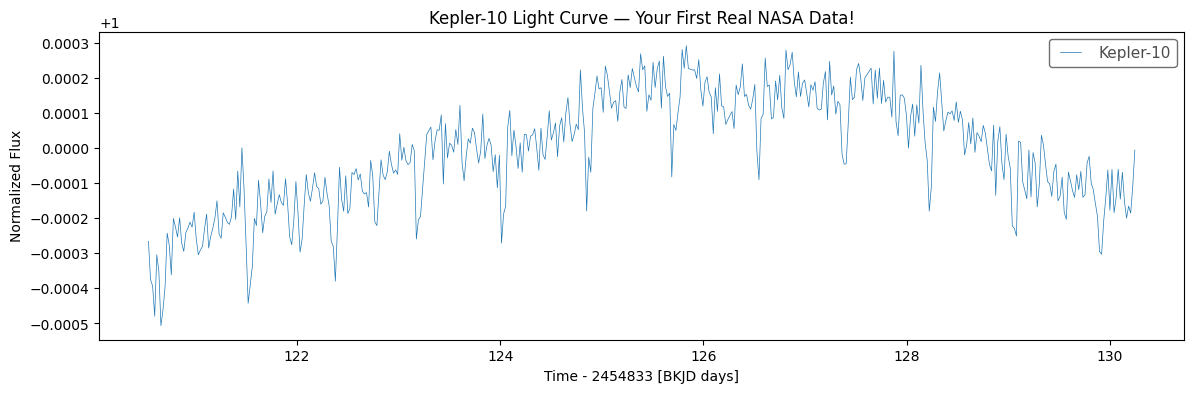


Time points: 469
Duration:    9.7 days


In [8]:
# Download first quarter and plot it
lc = search[0].download()
lc = lc.normalize().remove_outliers()

fig, ax = plt.subplots(figsize=(14, 4))
lc.plot(ax=ax, label='Kepler-10')
ax.set_title('Kepler-10 Light Curve — Your First Real NASA Data!')
plt.show()

print(f'\nTime points: {len(lc)}')
print(f'Duration:    {lc.time[-1].value - lc.time[0].value:.1f} days')

## All Done!
If all 6 cells ran without errors your environment is fully working:
- ✅ NumPy — matrix ops and eigenvalues
- ✅ Pandas + Sklearn — data loading and classification
- ✅ Matplotlib — visualization
- ✅ PyTorch — GPU tensor operations
- ✅ Lightkurve — real NASA Kepler data

**Next notebook:** After finishing the Neural Networks videos, open `01_light_curve_exploration.ipynb`